In [6]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
nr_of_seeds = 30 #nr of seeds in the experiments

In [8]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                avg_mae=('mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [9]:
# Define custom matplotlib colors by their index (only to get consistent colors with friedman vizes)
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_2396\1096666395.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_2396\1096666395.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_2396\1096666395.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

<Axes: xlabel='method', ylabel='rmse'>

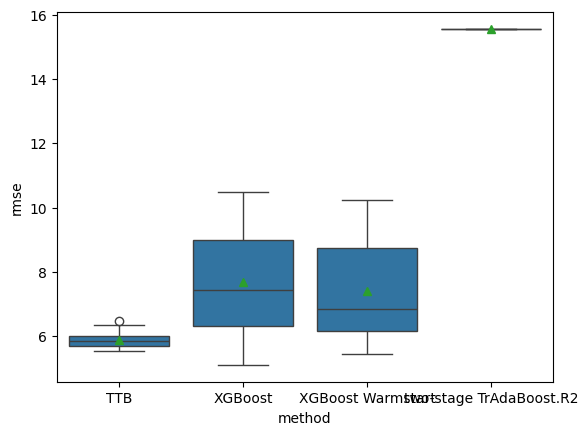

In [10]:
sub_name = 'normal'

dat = pd.read_csv(f'results_{sub_name}/ttb_LS.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results_{sub_name}/xgb.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'

data = pd.read_csv(f'results_{sub_name}/xgb_warmstart.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart ['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart , best_XGBoost_params_warmstart  = topk_per_d_per_method(
    xgboost_data_warmstart ,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost_warmstart ['method'] = 'XGBoost Warmstart'

data = pd.read_csv(f'results_{sub_name}/two_trada.csv')
trada_data = data
trada_data['method'] = 'two-stage TrAdaBoost.R2'

best_trada, best_trada_params = topk_per_d_per_method(
    trada_data,
['lr', 'n_estimators', 'n_estimators_fs', 'cv'], k=nr_of_seeds
)
best_trada['method'] = 'two-stage TrAdaBoost.R2'



df = best_LSTransferTreeBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
df = pd.concat([df, best_XGBoost_warmstart])
df = pd.concat([df, best_trada])
marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.boxplot(
data=df,
x='method', y='rmse', showmeans = True)





In [11]:
#Obtain best parameters in order based on test rmse
dat = pd.read_csv(f'results_{sub_name}/ttb_LS.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=100000
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results_{sub_name}/xgb.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=100000
)
best_XGBoost['method'] = 'XGBoost'

data = pd.read_csv(f'results_{sub_name}/xgb_warmstart.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart ['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart , best_XGBoost_params_warmstart  = topk_per_d_per_method(
    xgboost_data_warmstart ,
['v', 'target_tree_size'], k=100000
)
best_XGBoost_warmstart ['method'] = 'XGBoost Warmstart'

data = pd.read_csv(f'results_{sub_name}/two_trada.csv')
trada_data = data
trada_data['method'] = 'two-stage TrAdaBoost.R2'

best_trada, best_trada_params = topk_per_d_per_method(
    trada_data,
['lr', 'n_estimators', 'n_estimators_fs', 'cv'], k=100000
)
best_trada['method'] = 'two-stage TrAdaBoost.R2'

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_2396\855355129.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_2396\855355129.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_2396\855355129.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

In [12]:
#Get best params in order
best_LSTransferTreeBoost_params.iloc[::nr_of_seeds]

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,avg_mae,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
39,0.1,2.0,2.0,0.05,0.9,5.53693,4.150318,1,860.0,400.0,5.307932,4.089799,5.53693,4.150318,TransferTreeBoost
2,0.1,1.0,1.0,0.01,0.1,6.46127,4.470536,1,860.0,400.0,6.436295,4.880094,6.46127,4.470536,TransferTreeBoost


In [13]:
#Get best params in order
best_XGBoost_params.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
31,0.25,1.0,7.667327,5.296526,30,24,860.0,5.423591,4.295629,5.778960,4.700558,XGBoost
449,0.20,1.0,7.676217,5.295813,30,450,872.0,6.694305,4.877113,9.874339,5.953166,XGBoost
907,0.15,1.0,7.684421,5.299788,30,912,885.0,6.953153,4.994301,9.155508,5.585572,XGBoost
314,0.30,1.0,7.708554,5.325223,30,318,868.0,6.528519,4.811545,8.724078,5.932113,XGBoost
394,0.10,1.0,7.712538,5.321784,30,366,870.0,6.793395,4.625587,9.384687,5.248286,XGBoost
1063,0.05,1.0,7.743688,5.368816,30,1044,889.0,7.193561,5.221294,6.366846,4.589288,XGBoost
1055,0.30,2.0,7.745879,5.326084,30,1075,889.0,7.408533,4.872747,5.871504,4.058346,XGBoost
1076,0.20,2.0,7.769900,5.353391,30,1063,889.0,7.016019,4.956914,6.062380,4.299175,XGBoost
617,0.25,2.0,7.778056,5.351261,30,637,877.0,5.802606,3.964257,9.505899,5.258746,XGBoost
1067,0.10,2.0,7.782488,5.377099,30,1051,889.0,7.143399,5.162294,6.220405,4.426811,XGBoost


In [14]:
#Get best params in order
best_XGBoost_params_warmstart.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
1066,0.10,1.0,7.391076,5.086121,30,1050,889.0,6.912580,4.788257,6.255744,4.492178,XGBoost Warmstart
734,0.05,2.0,7.401940,5.139918,30,721,880.0,5.606561,4.377861,6.577153,4.902858,XGBoost Warmstart
980,0.15,1.0,7.402704,5.064288,30,984,887.0,9.434678,5.659739,6.189343,4.604578,XGBoost Warmstart
760,0.05,1.0,7.408938,5.108108,30,756,881.0,6.531243,5.423550,6.894153,4.644914,XGBoost Warmstart
555,0.25,1.0,7.413047,5.060357,30,564,875.0,5.515977,4.409915,7.624941,5.252628,XGBoost Warmstart
621,0.20,1.0,7.419271,5.062958,30,630,877.0,6.259796,4.293864,9.278606,5.045910,XGBoost Warmstart
1067,0.10,2.0,7.433349,5.117894,30,1051,889.0,6.958802,4.742311,6.203329,4.440695,XGBoost Warmstart
1054,0.30,1.0,7.446574,5.061100,30,1074,889.0,6.947550,4.683680,6.105217,4.237049,XGBoost Warmstart
634,0.15,2.0,7.450386,5.099949,30,625,877.0,6.042349,4.105383,9.130891,5.169995,XGBoost Warmstart
430,0.05,3.0,7.480648,5.173207,30,398,871.0,6.834441,4.846853,5.513410,4.062788,XGBoost Warmstart


In [15]:
best_trada_params.iloc[::nr_of_seeds]

,lr,n_estimators,n_estimators_fs,cv,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,rmse,mae,method
0,0.1,10.0,10.0,5.0,15.560175,12.680835,1,0,860.0,15.560175,12.680835,two-stage TrAdaBoost.R2


In [16]:
((best_XGBoost_params.iloc[0]['avg_rmse'] - best_LSTransferTreeBoost_params.iloc[0]['avg_rmse']) / best_XGBoost_params.iloc[0]['avg_rmse'])*100

np.float64(27.785389477013368)

In [17]:
import numpy as np
np.std(best_XGBoost_params.iloc[:30]['rmse'])

np.float64(1.4914600701793763)